# 04 - Cartographier une empreinte environnementale

Une carte permet de repérer rapidement des structures géographiques, mais elle impose aussi des choix de données, d’échelle et de représentation. Ce notebook cartographie les comptes climatiques calculés avec EXIOBASE 3.10.2 sans dépendre d’une bibliothèque SIG.

À la fin, vous saurez :

- relier les codes régionaux d’EXIOBASE à un fond de carte ;
- contrôler les régions qui ne peuvent pas être cartographiées ;
- comparer production et consommation avec une échelle commune ;
- représenter le solde entre les deux comptes ;
- expliquer les limites statistiques et visuelles d’une carte.

## 1. Une carte répond à une question précise

Nous comparerons trois informations pour l’année 2022 :

1. les émissions associées à la production observée dans chaque pays ;
2. l’empreinte de la consommation finale de chaque pays ;
3. leur différence, appelée ici solde de consommation.

Un solde positif signifie que l’empreinte de consommation dépasse les émissions de production. Il ne mesure ni un flux physique de CO2 à la frontière, ni un transfert financier.

## 2. Recalculer les comptes climatiques

Le périmètre et les facteurs de caractérisation sont identiques à ceux du notebook `02`. La production observée est calculée avec les émissions directes $F$ et $F_Y$. L’empreinte de consommation est calculée avec `D_cba_reg`.

In [1]:
from pathlib import Path
import json
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import LogNorm, TwoSlopeNorm
import numpy as np
import pandas as pd
import pymrio as mr

ANNEE = 2022
DOSSIER_EXIOBASE = Path("D:/EXIOBASE/3.10.2")
ARCHIVE_EXIOBASE = DOSSIER_EXIOBASE / f"IOT_{ANNEE}_ixi.zip"

if not ARCHIVE_EXIOBASE.exists():
    raise FileNotFoundError(
        f"Archive absente : {ARCHIVE_EXIOBASE}. "
        "Exécutez d’abord le notebook 00_préparer_EXIOBASE.ipynb."
    )

In [2]:
io = mr.parse_exiobase3(path=ARCHIVE_EXIOBASE)
_ = io.calc_system()
io.air_emissions.S = mr.calc_S(io.air_emissions.F, io.x).fillna(0)
_ = io.air_emissions.calc_system(x=io.x, Y=io.Y, L=io.L)
print("EXIOBASE chargée et comptes atmosphériques calculés.")

EXIOBASE chargée et comptes atmosphériques calculés.


In [3]:
index_emissions = io.air_emissions.F.index
facteurs_prg100 = pd.Series(0.0, index=index_emissions, name="PRG100")
noms_emissions = index_emissions.to_series().astype(str)

masque_co2_fossile = (
    noms_emissions.str.startswith("CO2 -")
    & ~noms_emissions.str.contains("biogenic", case=False)
)
masque_methane = noms_emissions.str.startswith(("CH4 -", "CH4_bio -"))
masque_methane_fossile = noms_emissions.str.contains(
    "Extraction/production|Mining of|Oil refinery", regex=True
)
masque_n2o = noms_emissions.str.startswith(("N2O -", "N2O_bio -"))

facteurs_prg100.loc[masque_co2_fossile] = 1.0
facteurs_prg100.loc[masque_methane] = 27.0
facteurs_prg100.loc[masque_methane & masque_methane_fossile] = 29.8
facteurs_prg100.loc[masque_n2o] = 273.0
if "SF6 - air" in facteurs_prg100.index:
    facteurs_prg100.loc["SF6 - air"] = 25_200.0

In [4]:
emissions_industries = facteurs_prg100 @ io.air_emissions.F.fillna(0)
emissions_finales = facteurs_prg100 @ io.air_emissions.F_Y.fillna(0)
emissions_finales_region = emissions_finales.groupby(level="region").sum()

production_observee = (
    emissions_industries.groupby(level="region").sum()
    + emissions_finales_region
)
consommation = facteurs_prg100 @ io.air_emissions.D_cba_reg

comptes_climat = pd.DataFrame(
    {
        "production observée": production_observee,
        "consommation": consommation,
    }
) * 1e-9
comptes_climat["solde de consommation"] = (
    comptes_climat["consommation"]
    - comptes_climat["production observée"]
)
comptes_climat.index.name = "région EXIOBASE"
comptes_climat.loc["FR"].rename("France, Mt CO2e").to_frame()

,"France, Mt CO2e"
production observée,401.198952
consommation,594.787105
solde de consommation,193.588153


## 3. Télécharger un fond de carte documenté

Nous utilisons le fond mondial des pays 2024 de GISCO, le service géographique de la Commission européenne, à une résolution de 20 millions et dans le système de coordonnées WGS84. Le fichier GeoJSON fait environ 2 Mo et n’est téléchargé qu’une fois.

Source : [GISCO, Countries 2024](https://gisco-services.ec.europa.eu/distribution/v2/countries/).

L’année du fond cartographique décrit les frontières du fichier, pas l’année des données environnementales.

In [5]:
URL_CARTE = (
    "https://gisco-services.ec.europa.eu/distribution/v2/countries/geojson/"
    "CNTR_RG_20M_2024_4326.geojson"
)
DOSSIER_CARTO = DOSSIER_EXIOBASE / "cartographie"
FICHIER_CARTE = DOSSIER_CARTO / "CNTR_RG_20M_2024_4326.geojson"

if not FICHIER_CARTE.exists():
    DOSSIER_CARTO.mkdir(parents=True, exist_ok=True)
    requete = Request(URL_CARTE, headers={"User-Agent": "Mozilla/5.0"})
    with urlopen(requete, timeout=60) as reponse:
        FICHIER_CARTE.write_bytes(reponse.read())
    print(f"Fond de carte téléchargé : {FICHIER_CARTE}")
else:
    print(f"Fond de carte déjà présent : {FICHIER_CARTE}")

Fond de carte déjà présent : D:\EXIOBASE\3.10.2\cartographie\CNTR_RG_20M_2024_4326.geojson


In [6]:
with FICHIER_CARTE.open(encoding="utf-8") as fichier:
    fond_carte = json.load(fichier)

assert fond_carte["type"] == "FeatureCollection"
assert all(
    "ISO3_CODE" in objet["properties"]
    for objet in fond_carte["features"]
)
print(f"{len(fond_carte['features'])} entités géographiques chargées.")

263 entités géographiques chargées.


## 4. Construire et contrôler la jointure

EXIOBASE utilise des codes à deux lettres pour les pays et des codes particuliers pour cinq régions regroupant le reste du monde. GISCO fournit des codes ISO à trois lettres. La concordance ci-dessous est volontairement explicite et vérifiable.

In [7]:
exio_vers_iso3 = {
    "AT": "AUT", "BE": "BEL", "BG": "BGR", "CY": "CYP",
    "CZ": "CZE", "DE": "DEU", "DK": "DNK", "EE": "EST",
    "ES": "ESP", "FI": "FIN", "FR": "FRA", "GR": "GRC",
    "HR": "HRV", "HU": "HUN", "IE": "IRL", "IT": "ITA",
    "LT": "LTU", "LU": "LUX", "LV": "LVA", "MT": "MLT",
    "NL": "NLD", "PL": "POL", "PT": "PRT", "RO": "ROU",
    "SE": "SWE", "SI": "SVN", "SK": "SVK", "GB": "GBR",
    "US": "USA", "JP": "JPN", "CN": "CHN", "CA": "CAN",
    "KR": "KOR", "BR": "BRA", "IN": "IND", "MX": "MEX",
    "RU": "RUS", "AU": "AUS", "CH": "CHE", "TR": "TUR",
    "TW": "TWN", "NO": "NOR", "ID": "IDN", "ZA": "ZAF",
}
regions_agregees = {"WA", "WL", "WE", "WF", "WM"}

assert set(io.get_regions()) == set(exio_vers_iso3) | regions_agregees
pd.Series(exio_vers_iso3, name="code ISO3").rename_axis("code EXIOBASE").to_frame()

,code ISO3
code EXIOBASE,
AT,AUT
BE,BEL
BG,BGR
CY,CYP
CZ,CZE
DE,DEU
DK,DNK
EE,EST
ES,ESP


In [8]:
codes_gisco = {
    objet["properties"]["ISO3_CODE"] for objet in fond_carte["features"]
}
regions_sans_geometrie = [
    region
    for region in io.get_regions()
    if exio_vers_iso3.get(region) not in codes_gisco
]

couverture = pd.DataFrame(
    {
        "nombre de régions": [
            len(io.get_regions()) - len(regions_sans_geometrie),
            len(regions_sans_geometrie),
        ],
        "empreinte de consommation (Mt CO2e)": [
            comptes_climat.drop(index=regions_sans_geometrie)["consommation"].sum(),
            comptes_climat.loc[regions_sans_geometrie, "consommation"].sum(),
        ],
    },
    index=["cartographiées", "sans géométrie distincte"],
)
display(couverture)
display(comptes_climat.loc[regions_sans_geometrie].round(1))

,nombre de régions,empreinte de consommation (Mt CO2e)
cartographiées,43,35797.622955
sans géométrie distincte,6,10495.725221


,production observée,consommation,solde de consommation
région EXIOBASE,,,
TW,319.6,297.7,-22.0
WA,3465.7,3792.3,326.5
WL,1270.3,1324.3,54.1
WE,368.3,320.6,-47.7
WF,2306.2,2380.4,74.2
WM,3065.1,2380.4,-684.7


Les régions `WA`, `WL`, `WE`, `WF` et `WM` regroupent plusieurs pays : elles ne possèdent pas de polygone unique. Le fond GISCO ne fournit pas non plus de géométrie distincte pour `TW`. Ces valeurs restent dans les totaux et sont affichées dans le tableau, mais pas sur la carte.

Attribuer les valeurs de ces régions à des pays particuliers nécessiterait une clé de désagrégation supplémentaire. Une simple jointure cartographique ne peut pas produire cette information.

## 5. Dessiner le GeoJSON avec Matplotlib

Un objet GeoJSON contient des polygones simples ou multiples. La fonction suivante extrait leur contour extérieur, associe une valeur à chaque code ISO3 et colore les pays. Les entités sans valeur EXIOBASE apparaissent en gris.

Cette méthode légère suffit pour une carte mondiale pédagogique. Une analyse spatiale avancée nécessiterait une bibliothèque SIG et une gestion explicite des projections.

In [9]:
def contours_exterieurs(geometrie):
    if geometrie["type"] == "Polygon":
        return [geometrie["coordinates"][0]]
    if geometrie["type"] == "MultiPolygon":
        return [polygone[0] for polygone in geometrie["coordinates"]]
    return []


def tracer_carte(axe, serie_exio, titre, cmap, norme):
    serie_iso3 = serie_exio.rename(index=exio_vers_iso3)
    polygones = []
    valeurs = []

    for objet in fond_carte["features"]:
        code = objet["properties"]["ISO3_CODE"]
        contours = contours_exterieurs(objet["geometry"])
        polygones.extend(contours)
        valeurs.extend([serie_iso3.get(code, np.nan)] * len(contours))

    palette = plt.get_cmap(cmap).copy()
    palette.set_bad("#D9D9D9")
    collection = PolyCollection(
        polygones,
        array=np.ma.masked_invalid(np.asarray(valeurs, dtype=float)),
        cmap=palette,
        norm=norme,
        edgecolors="white",
        linewidths=0.25,
    )
    axe.add_collection(collection)
    axe.set(
        xlim=(-180, 180), ylim=(-60, 90),
        aspect="equal", title=titre, xlabel="longitude", ylabel="latitude",
    )
    return collection

## 6. Comparer production et consommation

Les deux cartes utilisent la même échelle de couleurs. Une couleur donnée représente donc la même quantité dans les deux panneaux. L’échelle logarithmique permet de montrer simultanément des économies de tailles très différentes, mais elle réduit visuellement les écarts entre grandes valeurs.

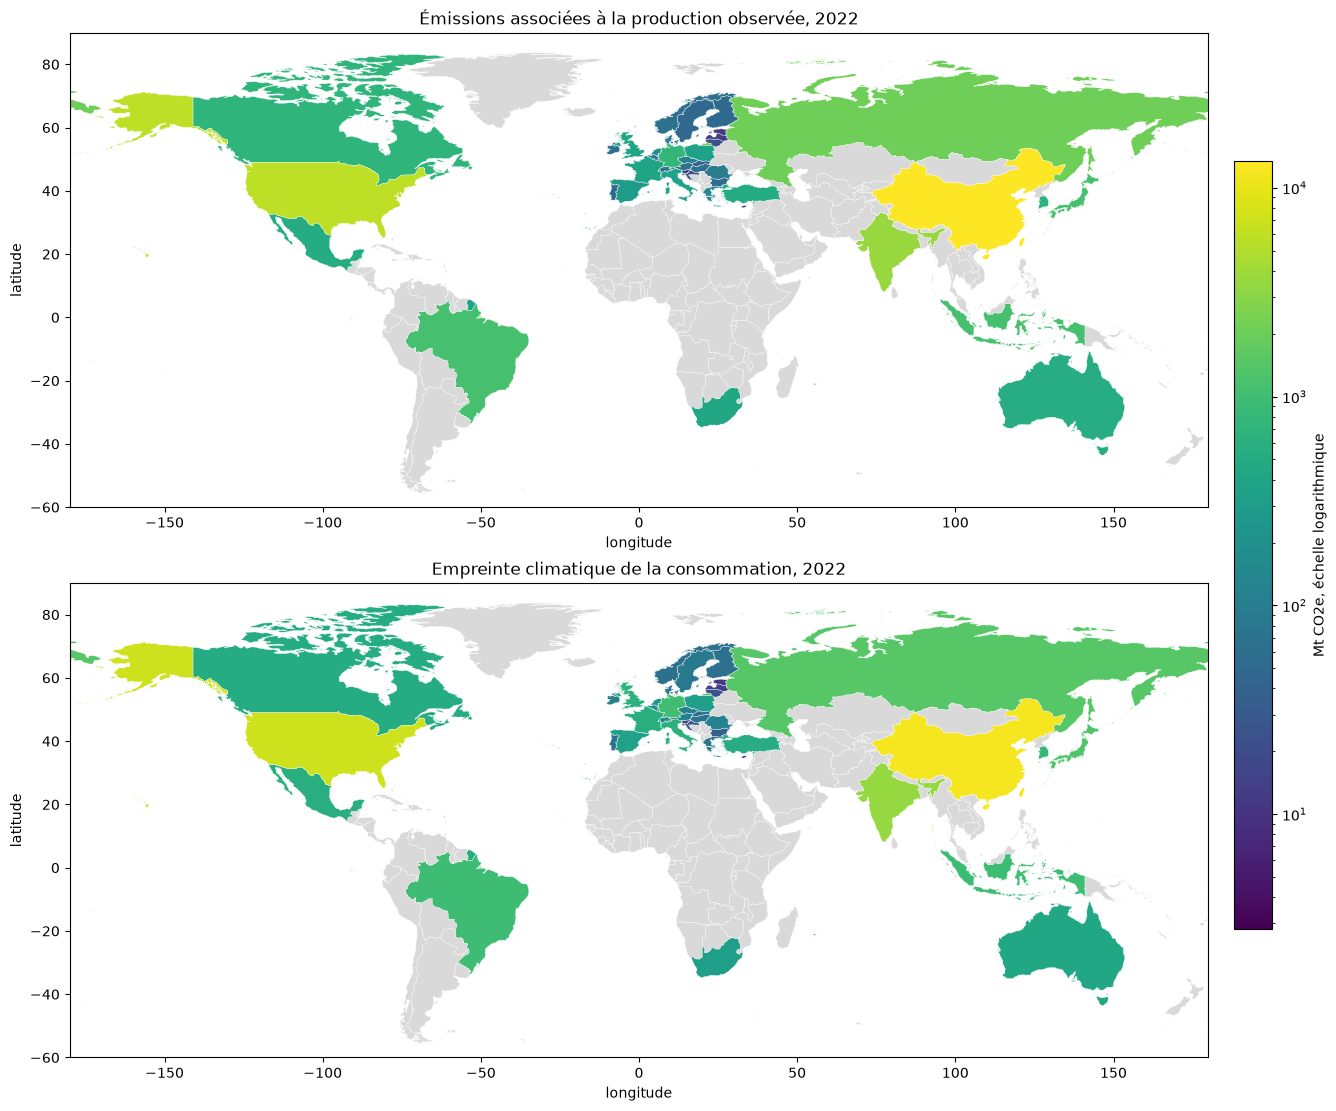

In [10]:
valeurs_absolues = comptes_climat[["production observée", "consommation"]]
valeurs_positives = valeurs_absolues.to_numpy()
valeurs_positives = valeurs_positives[valeurs_positives > 0]
norme_absolue = LogNorm(
    vmin=valeurs_positives.min(), vmax=valeurs_positives.max()
)

fig, axes = plt.subplots(
    nrows=2, figsize=(14, 11), constrained_layout=True
)
carte = tracer_carte(
    axes[0], comptes_climat["production observée"],
    f"Émissions associées à la production observée, {ANNEE}",
    "viridis", norme_absolue,
)
tracer_carte(
    axes[1], comptes_climat["consommation"],
    f"Empreinte climatique de la consommation, {ANNEE}",
    "viridis", norme_absolue,
)
barre = fig.colorbar(carte, ax=axes, shrink=0.75, pad=0.02)
barre.set_label("Mt CO2e, échelle logarithmique")

## 7. Cartographier le solde de consommation

La différence entre consommation et production est représentée avec une palette divergente centrée sur zéro :

- en rouge, l’empreinte de consommation est supérieure aux émissions de production ;
- en bleu, les émissions de production sont supérieures à l’empreinte de consommation ;
- près du blanc, les deux comptes sont proches.

La production observée conserve les pressions associées aux colonnes de production monétaire nulle, contrairement aux comptes attribuables. Le solde ne correspond donc pas exactement à `D_imp - D_exp`, comme expliqué dans le notebook `02`.

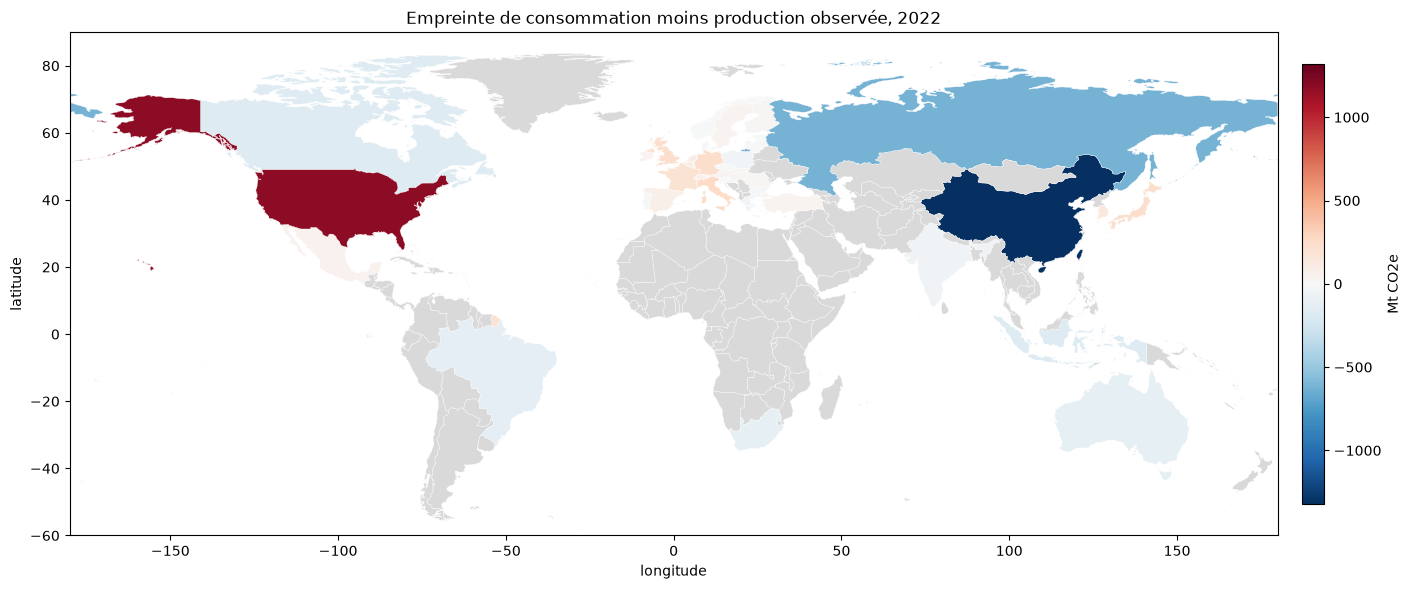

In [11]:
solde = comptes_climat["solde de consommation"]
limite = solde.abs().max()
norme_solde = TwoSlopeNorm(vmin=-limite, vcenter=0, vmax=limite)

fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)
carte = tracer_carte(
    ax, solde,
    f"Empreinte de consommation moins production observée, {ANNEE}",
    "RdBu_r", norme_solde,
)
barre = fig.colorbar(carte, ax=ax, shrink=0.75, pad=0.02)
barre.set_label("Mt CO2e")

## 8. Compléter la carte par un tableau

Une carte montre une structure spatiale, mais elle permet difficilement de lire des valeurs précises. Un classement complète donc l’information et inclut aussi les régions qui n’ont pas de géométrie distincte.

In [12]:
plus_importateurs = comptes_climat.nlargest(8, "solde de consommation")
plus_exportateurs = comptes_climat.nsmallest(8, "solde de consommation")

pd.concat(
    {
        "soldes positifs les plus élevés": plus_importateurs.reset_index(drop=False),
        "soldes négatifs les plus élevés": plus_exportateurs.reset_index(drop=False),
    },
    axis=1,
).round(1)

soldes positifs les plus élevés                                   \
                  région EXIOBASE production observée consommation   
0                              US              5775.8       6955.9   
1                              WA              3465.7       3792.3   
2                              IT               369.9        630.0   
3                              GB               420.4        655.9   
4                              DE               766.9        998.9   
5                              JP              1095.6       1324.1   
6                              FR               401.2        594.8   
7                              KR               649.8        789.8   

                        soldes négatifs les plus élevés                      \
  solde de consommation                 région EXIOBASE production observée   
0                1180.1                              CN             13469.8   
1                 326.5                              WM              3065.1   
2                 260.0                              RU              2062.5   
3                 235.5                              ID              1097.9   
4                 232.0                              CA               684.8   
5                 228.5                              BR              1094.5   
6                 193.6                              ZA               431.9   
7                 140.0                              AU               553.5   

                                      
  consommation solde de consommation  
0      12150.5               -1319.4  
1       2380.4                -684.7  
2       1435.3                -627.1  
3        925.1                -172.7  
4        518.5                -166.3  
5        965.7                -128.8  
6        310.7                -121.2  
7        438.8                -114.7

## 9. Limites à documenter

Une carte ne doit pas être interprétée sans préciser :

- les années des données environnementales et du fond cartographique ;
- les régions EXIOBASE non représentées spatialement ;
- le périmètre des gaz et les facteurs de caractérisation ;
- la différence entre production observée et production attribuable ;
- l’échelle logarithmique ou linéaire employée ;
- la projection cartographique ;
- l’effet visuel de la superficie des pays.

Les cartes en valeurs absolues mettent surtout en évidence les grandes économies. Une carte par habitant répondrait à une autre question et nécessiterait une source démographique compatible, documentée et alignée sur le même millésime.

## 10. Questions pour guider l’interprétation

1. Quels pays changent le plus de position entre les comptes de production et de consommation ?
2. La carte du solde confirme-t-elle le classement numérique ?
3. Quelle part de l’empreinte mondiale n’est pas visible sur la carte ?
4. Pourquoi serait-il incorrect de répartir uniformément une région agrégée entre ses pays ?
5. Quel indicateur faudrait-il choisir pour étudier les différences de modes de vie plutôt que la taille des économies ?

## À retenir

- une jointure entre données statistiques et géographiques doit être contrôlée ;
- une absence de géométrie ne signifie pas une valeur environnementale nulle ;
- deux cartes comparées doivent partager la même échelle ;
- une palette divergente doit être centrée sur la valeur de référence ;
- une carte et un tableau répondent à des besoins complémentaires ;
- les choix cartographiques font partie de la méthode et doivent être documentés.